<a href="https://colab.research.google.com/github/meghanavanamala/predictiveanalysis/blob/loanapprovalprediction/loanapprovalprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Accuracy: 0.855

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.81      0.86       113
           1       0.78      0.92      0.85        87

    accuracy                           0.85       200
   macro avg       0.86      0.86      0.85       200
weighted avg       0.87      0.85      0.86       200


📉 Confusion Matrix:
 [[91 22]
 [ 7 80]]


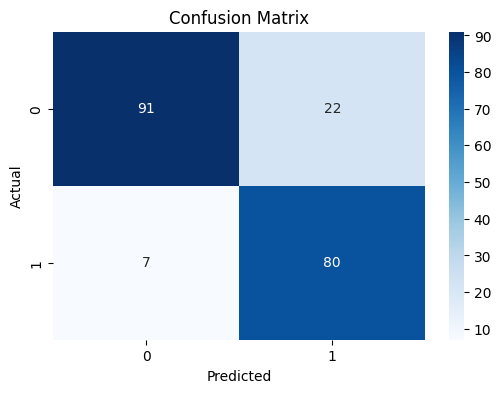

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


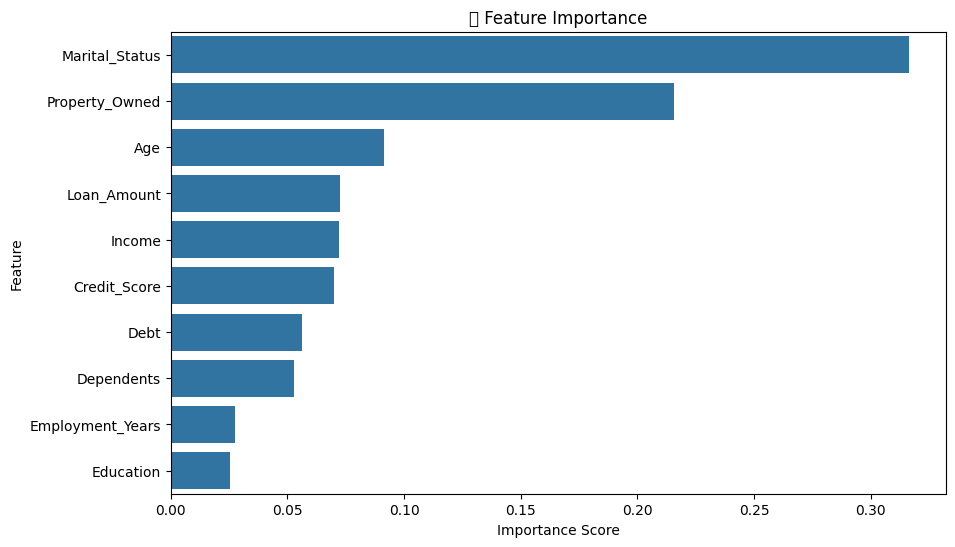

In [1]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Generate a Synthetic Dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=6,
                           n_redundant=2, n_classes=2, random_state=42)

# Convert to DataFrame
feature_names = ['Credit_Score', 'Income', 'Loan_Amount', 'Employment_Years', 'Debt',
                 'Marital_Status', 'Education', 'Age', 'Dependents', 'Property_Owned']

df = pd.DataFrame(X, columns=feature_names)
df['Loan_Approved'] = y

# Step 3: Split Dataset into Train and Test Sets
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 5: Make Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate the Model
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))
print("\n📉 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 7: Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 8: Feature Importance Plot
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices])
plt.title("🔍 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
